# MNIST Neural Network (Research-Grade)
CS229-style + Validation + Regularization + Mini-batch SGD + GD Visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

2026-04-29 00:52:59.538195: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-29 00:52:59.538457: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 00:52:59.603980: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 00:53:01.048524: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

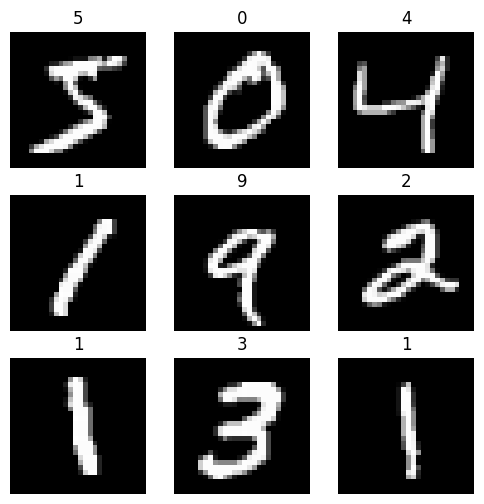

In [2]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(Y_train[i])
    plt.axis('off')
plt.show()

In [3]:
X_train = X_train.reshape(-1, 784).T / 255.0
X_test = X_test.reshape(-1, 784).T / 255.0

def one_hot(Y):
    oh = np.zeros((10, Y.size))
    oh[Y, np.arange(Y.size)] = 1
    return oh

m = X_train.shape[1]
val_size = int(0.1*m)

X_val = X_train[:, :val_size]
Y_val = Y_train[:val_size]
Y_val_oh = one_hot(Y_val)

X_train = X_train[:, val_size:]
Y_train = Y_train[val_size:]
Y_train_oh = one_hot(Y_train)

In [4]:
def relu(Z): return np.maximum(0,Z)
def relu_deriv(Z): return (Z>0).astype(float)

def softmax(Z):
    Zs = Z - np.max(Z,axis=0,keepdims=True)
    e = np.exp(Zs)
    return e/np.sum(e,axis=0,keepdims=True)

def init():
    W1 = np.random.randn(256,784)*np.sqrt(2/784)
    b1 = np.zeros((256,1))
    W2 = np.random.randn(128,256)*np.sqrt(2/256)
    b2 = np.zeros((128,1))
    W3 = np.random.randn(10,128)*np.sqrt(2/128)
    b3 = np.zeros((10,1))
    return W1,b1,W2,b2,W3,b3

In [5]:
def forward(X,W1,b1,W2,b2,W3,b3):
    Z1=W1@X+b1; A1=relu(Z1)
    Z2=W2@A1+b2; A2=relu(Z2)
    Z3=W3@A2+b3; A3=softmax(Z3)
    return (Z1,A1,Z2,A2,Z3,A3)

In [6]:
def cost(A3,Y,W1,W2,W3,lam=0.01):
    m=Y.shape[1]
    ce = -np.sum(Y*np.log(A3+1e-8))/m
    reg = lam/(2*m)*(np.sum(W1**2)+np.sum(W2**2)+np.sum(W3**2))
    return ce+reg

In [7]:
def backward(X,Y,cache,W1,W2,W3,lam=0.01):
    Z1,A1,Z2,A2,Z3,A3 = cache
    m=X.shape[1]

    dZ3=A3-Y
    dW3=(dZ3@A2.T)/m + (lam/m)*W3
    db3=np.sum(dZ3,axis=1,keepdims=True)/m

    dZ2=(W3.T@dZ3)*relu_deriv(Z2)
    dW2=(dZ2@A1.T)/m + (lam/m)*W2
    db2=np.sum(dZ2,axis=1,keepdims=True)/m

    dZ1=(W2.T@dZ2)*relu_deriv(Z1)
    dW1=(dZ1@X.T)/m + (lam/m)*W1
    db1=np.sum(dZ1,axis=1,keepdims=True)/m

    return dW1,db1,dW2,db2,dW3,db3

In [8]:
def update(params,grads,lr):
    return [p - lr*g for p,g in zip(params,grads)]

In [9]:
def train(X,Y,epochs=5,lr=0.1,bs=64):
    W1,b1,W2,b2,W3,b3 = init()
    losses=[]; val_accs=[]
    m=X.shape[1]

    for e in range(epochs):
        perm=np.random.permutation(m)
        Xs=X[:,perm]; Ys=Y[:,perm]

        for i in range(0,m,bs):
            Xb=Xs[:,i:i+bs]; Yb=Ys[:,i:i+bs]
            cache=forward(Xb,W1,b1,W2,b2,W3,b3)
            grads=backward(Xb,Yb,cache,W1,W2,W3)
            W1,b1,W2,b2,W3,b3 = update([W1,b1,W2,b2,W3,b3], grads, lr)

        _,_,_,_,_,A3 = forward(X,W1,b1,W2,b2,W3,b3)
        losses.append(cost(A3,Y,W1,W2,W3))

        _,_,_,_,_,A3v = forward(X_val,W1,b1,W2,b2,W3,b3)
        val_accs.append(np.mean(np.argmax(A3v,axis=0)==Y_val))

        print(e, losses[-1], val_accs[-1])

    return W1,b1,W2,b2,W3,b3,losses,val_accs

In [10]:
W1,b1,W2,b2,W3,b3,losses,val_accs = train(X_train,Y_train_oh)

0 0.18565537363628498 0.9491666666666667
1 0.11513001770229316 0.9645
2 0.0887055504430334 0.9686666666666667
3 0.06733128590663223 0.9745
4 0.04904666601863998 0.9766666666666667


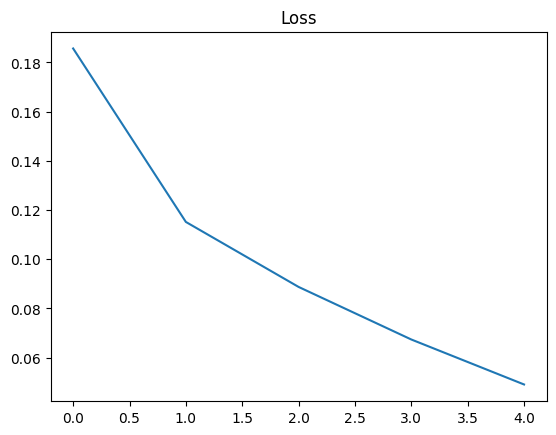

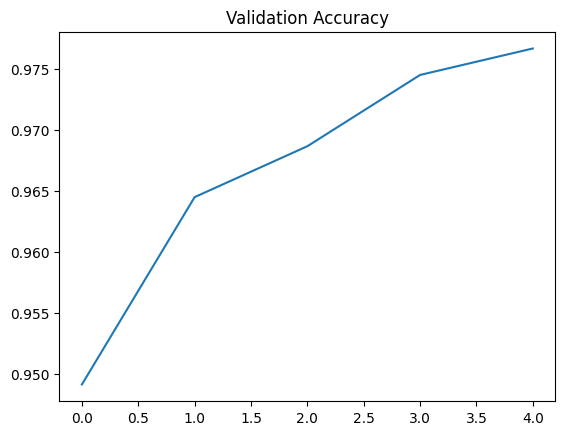

In [11]:
plt.figure()
plt.plot(losses)
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(val_accs)
plt.title("Validation Accuracy")
plt.show()

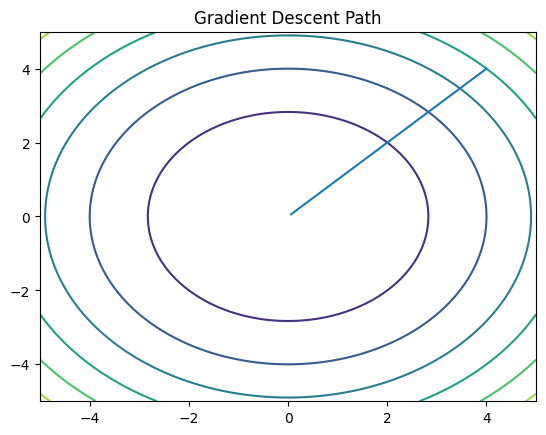

In [12]:
def f(x,y): return x**2 + y**2

x,y = np.meshgrid(np.linspace(-5,5,100), np.linspace(-5,5,100))
z = f(x,y)

path = []
px,py = 4,4

lr=0.1
for _ in range(20):
    path.append((px,py))
    px -= lr*2*px
    py -= lr*2*py

path = np.array(path)

plt.figure()
plt.contour(x,y,z)
plt.plot(path[:,0], path[:,1])
plt.title("Gradient Descent Path")
plt.show()